In [1]:
import requests
from PIL import Image

import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
import os
import matplotlib.pyplot as plt 

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model

In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '0'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [3]:
model_id = "llava-hf/llava-1.5-7b-hf"
model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
    low_cpu_mem_usage=True, 
    cache_dir='/data/takis/models'
).to(device)

processor = AutoProcessor.from_pretrained(model_id, cache_dir='/data/takis/models')


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  5.97it/s]
Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens. 


# Example run

In [4]:
conversation = [
    {

      "role": "user",
      "content": [
          {"type": "text", "text": "Describe the image in detail."},
          {"type": "image"},
        ],
    },
]
prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)


In [92]:
image_file = "http://images.cocodataset.org/val2017/000000336232.jpg"
raw_image = Image.open(requests.get(image_file, stream=True).raw)
inputs = processor(images=raw_image, text=prompt, return_tensors='pt').to(device, torch.float16)

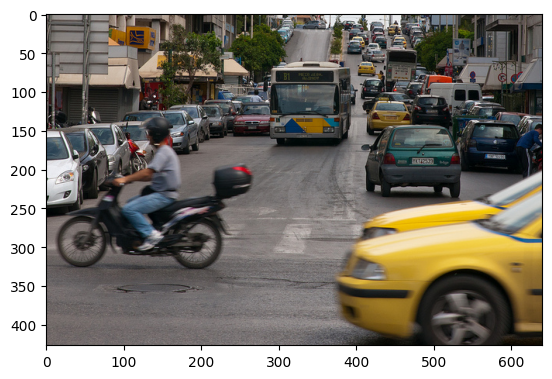

In [93]:
plt.imshow(raw_image)
plt.show()

In [102]:
# strength = 0

# output = model.generate(**inputs, max_new_tokens=512, do_sample=True, top_k=None, top_p=1, temperature=1)
# print(processor.decode(output[0][2:], skip_special_tokens=True))

for strength in [0, 11]:
    print (strength)

    output = model.generate(**inputs, max_new_tokens=512, do_sample=True)
    print(processor.decode(output[0][2:], skip_special_tokens=True))

0
ER:  
Describe the image in detail. ASSISTANT: The image captures a traffic-filled street where several vehicles are seen driving or driving down the hill. A motorcycle and a car sit among buses and cars, all navigating the busy road together. There are traffic lights in the scene, directing the flow of traffic.

People can also be seen in the image. One person is on a motorcycle, and another person can be spotted standing near a car. Two additional pedestrians are visible in the middle part of the scene, likely waiting to cross the busy road or engaging in other activities.
11
ER:  
Describe the image in detail. ASSISTANT: The image depicts a busy and crowded street filled with a plethora of vehicles. There is a line of cars, including a bus, driving down the street, while a motorcycle is seen weaving its way through the traffic. People in various positions are also present on the street, some riding motorcycles, while others are busy walking amidst the traffic.

Several cars are fo

# Forward hook reminder

In [78]:
target_layer = 20

In [77]:
hook.remove()

In [79]:
concept = None

def remind_image(target_layer):
    global concept
    def hook(model, input, output):
        global concept
        if (output[0].shape[1] != 1):
            concept = torch.mean(output[0], dim=1)
        else:
            output = (output[0] + strength*concept, *output[1:])
        return output
    return hook


hook = model.language_model.model.layers[target_layer].self_attn.register_forward_hook(remind_image(target_layer))

In [36]:

for strength in [11]:
    print (strength)

    output = model.generate(**inputs, max_new_tokens=512, do_sample=True, top_k=None, top_p=1, temperature=1)
    print(processor.decode(output[0][2:], skip_special_tokens=True))

11
ER:  
Describe the image in detail. ASSISTANT: The image shows a motorcycle parked outside a garage. The motorcycle is positioned close to vehicles like a jeep and a truck. There are two bikes in the scene, with one attached to the back of the motorcycle, likely a towbike.

In addition to the motorcycle, there is an old car sitting next to it, leaning against the nearby garage. A shovel is visible in the scene, with half of it protruding out of the garage and the other half lying at the motorcycle side. A dirt bike is parked here next to the towbike. There is also a dog sitting close to the back bike, possibly a pet of the owner of the motorcycle.
